In [1]:
# Install datasets library
!pip install datasets

# Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [2]:
df['job_posted_month'] = df.job_posted_date.dt.strftime('%b')

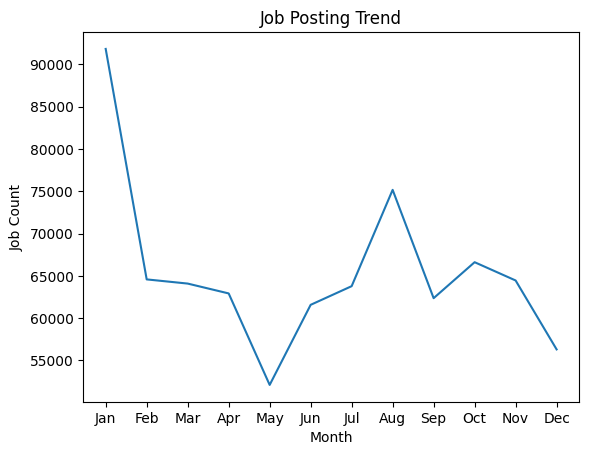

In [3]:
# Define chronological order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Sort and Plot
job_count = df['job_posted_month'].value_counts().reindex(month_order)

plt.plot(job_count.index, job_count.values)
plt.ylabel('Job Count')
plt.xlabel('Month')
plt.title('Job Posting Trend')
plt.show()

In [4]:
job_postings = df['job_title_short'].value_counts()
job_postings

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


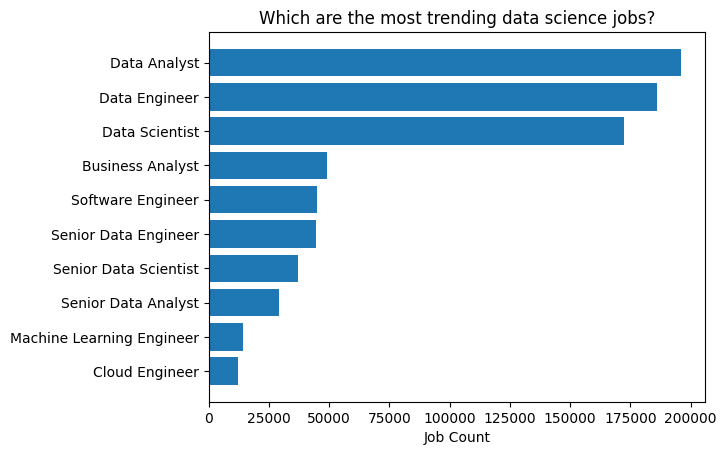

In [5]:
job_postings = job_postings.sort_values(ascending=True)

plt.barh(job_postings.index, job_postings.values)
plt.title('Which are the most trending data science jobs?')
plt.xlabel('Job Count')
plt.show()

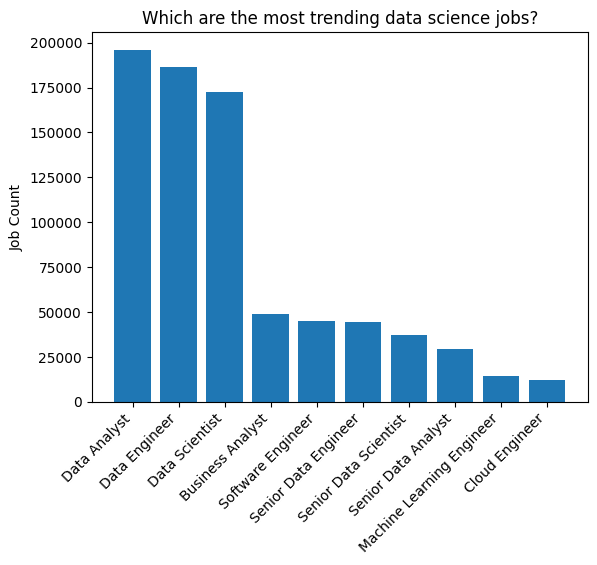

In [6]:
job_postings = job_postings.sort_values(ascending=False)

plt.bar(job_postings.index, job_postings.values)
plt.title('Which are the most trending data science jobs?')
plt.ylabel('Job Count')
plt.xticks(rotation=45, ha='right')
plt.show()

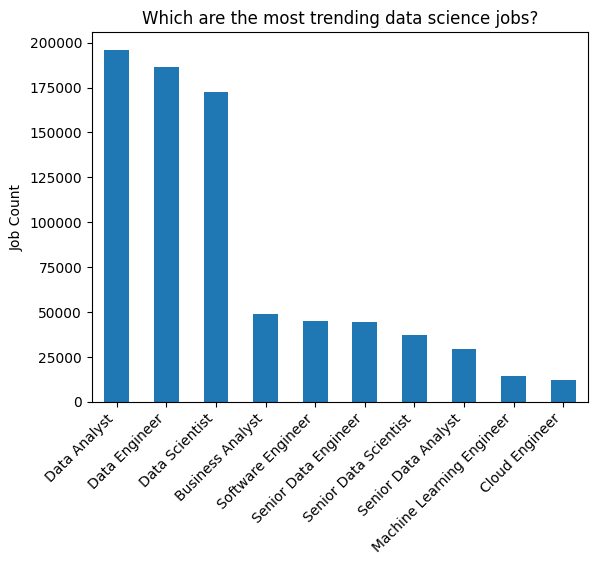

In [7]:
job_postings.plot(kind='bar')
plt.title('Which are the most trending data science jobs?')
plt.ylabel('Job Count')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.show()

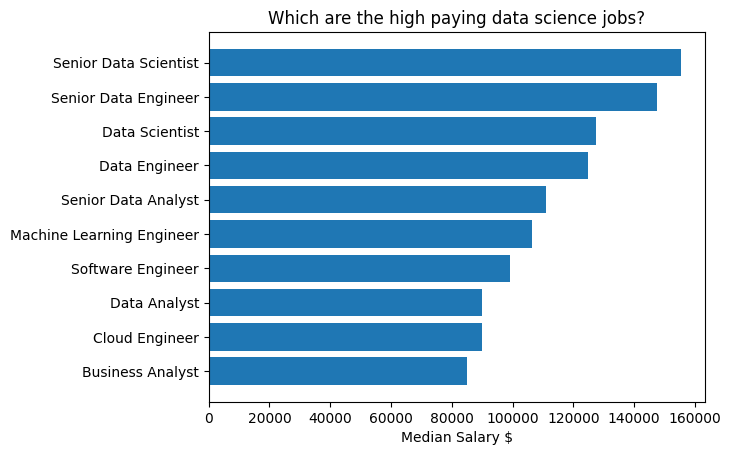

In [17]:
median_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=True)

plt.barh(median_salary.index, median_salary.values)
plt.title('Which are the high paying data science jobs?')
plt.xlabel('Median Salary $')
plt.show()